In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [7]:
court_docs = pd.read_csv("data/indiasandwatch/court_docs.csv", header=1)
mining = pd.read_csv("data/indiasandwatch/mining_obs.csv", header=1)
news = pd.read_csv("data/indiasandwatch/news_reports.csv", header=1)

In [8]:
news.columns

Index(['Title', 'States', 'District', 'PDF',
       'Number of streams identified for mining', 'Rivers / Streams',
       'Total number of Identified/ proposed mining locations',
       'Identified sand potential (cubic metres)',
       'Identified sand potential (tonnes)', 'Additional notes',
       ...
       'main.quarrySpecific.45.Polygon points', 'main.quarrySpecific.45.Notes',
       'main.quarrySpecific.46.Sub district name',
       'main.quarrySpecific.46.Rivers',
       'main.quarrySpecific.46.Polygon points', 'main.quarrySpecific.46.Notes',
       'main.quarrySpecific.47.Sub district name',
       'main.quarrySpecific.47.Rivers',
       'main.quarrySpecific.47.Polygon points',
       'main.quarrySpecific.47.Notes'],
      dtype='object', length=272)

In [5]:
mining.columns

Index(['Title', 'Would you like to submit this report anonymously?',
       'Date of Observation', 'Location', 'Are machines used in the process?',
       'Can you specify types of machines/ equipment',
       'Notes from the location', 'Pictures', 'State', 'District', 'River',
       'Published Date'],
      dtype='object')

In [6]:
court_docs.columns

Index(['Title', 'Link to the case on court sites / other sites', 'PDF',
       'Type of Document', 'Summary',
       'Start Date/ Registration date/ original application date of the case (as applicable)',
       'Application number / case number / diary number (as applicable)',
       'Type of Application', 'Case status', 'Date of case disposal', 'Judges',
       'Petitioner', 'Counsel for petitioner', 'Respondent',
       'Counsel for respondent',
       'Committees Set Up: Authorities/Expert Members',
       'Committees: Reports & Recommendations',
       'Committees: Date of set up and duration', 'Additional notes',
       'What is the focus area for this case?', 'State', 'District',
       'Sub district / Tehsil', 'Rivers / Streams', 'Court', 'High Court',
       'National Green Tribunal (NGT) zone/bench', 'Published Date'],
      dtype='object')

In [15]:
court_docs.shape

(91, 28)

In [16]:
court_docs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 28 columns):
 #   Column                                                                                Non-Null Count  Dtype 
---  ------                                                                                --------------  ----- 
 0   Title                                                                                 91 non-null     object
 1   Link to the case on court sites / other sites                                         89 non-null     object
 2   PDF                                                                                   84 non-null     object
 3   Type of Document                                                                      89 non-null     object
 4   Summary                                                                               90 non-null     object
 5   Start Date/ Registration date/ original application date of the case (as applicable)  90 non-n

In [34]:
court_docs.head(5)

,Title,Link to the case on court sites / other sites,PDF,Type of Document,Summary,Start Date/ Registration date/ original application date of the case (as applicable),Application number / case number / diary number (as applicable),Type of Application,Case status,Date of case disposal,...,Additional notes,What is the focus area for this case?,State,District,Sub district / Tehsil,Rivers / Streams,Court,High Court,National Green Tribunal (NGT) zone/bench,Published Date
0,Deepak Kumar Etc vs State Of Haryana & Ors.Etc...,https://indiankanoon.org/doc/60071241/#:~:text...,https://storage.googleapis.com/download/storag...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Haryana,NaN,NaN,"yamuna, Ghaggar, Tangri, Markanda, Krishnavati...",Supreme Court,NaN,NaN,06-01-2023
1,"Court Order, 21/07/2023 - Munish vs Haryana St...",https://greentribunal.gov.in/gen_pdf_test.php?...,https://storage.googleapis.com/download/storag...,Orders,Major comment (1) + instructions (2)\n\n1. The...,17-04-2023 18:30:00,OA 269 / 2023,Original Application,Pending,NaN,...,-,Regional,Haryana,Sonipat,NaN,yamuna,National Green Tribunal (NGT),NaN,North zone - Delhi (Principal bench),08-08-2023
2,"Court Order, 05/08/2022 - Akshay Kumar Tripath...",https://greentribunal.gov.in/caseDetails/KOLKA...,https://storage.googleapis.com/download/storag...,Orders,The matter related to illegal mining of sand i...,22-09-2021 18:30:00,OA 84 / 2021,Original Application,Disposed,05-08-2022 18:30:00,...,-,Regional,Odisha,Bhadrak,Bhandari Pokhari,Baitrani,National Green Tribunal (NGT),NaN,East zone - Kolkata,11-08-2023
3,"Court Order, 06/02/2023 - News item published ...",https://greentribunal.gov.in/caseDetails/DELHI...,NaN,Orders,The matter was taken up on the basis of a medi...,30-03-2022 18:30:00,OA 248 / 2022,Original Application,Pending,NaN,...,https://www.thehindu.com/society/an-ecocide-is...,Regional,Rajasthan,Dhaulpur,NaN,Chambal,National Green Tribunal (NGT),NaN,North zone - Delhi (Principal bench),17-08-2023
4,"Court Order, 29/09/2022 - Ajit Kumar vs State ...",https://greentribunal.gov.in/caseDetails/BHOPA...,NaN,Orders,The issue of non-compliance of sustainable San...,07-05-2022 18:30:00,OA 38 / 2022,Original Application,Disposed,29-09-2022 18:30:00,...,-,Regional,Madhya Pradesh,Dewas,NaN,"Narmada, Kali Sindh, Shipra",National Green Tribunal (NGT),NaN,Central zone - Bhopal,21-08-2023


In [17]:
crime = pd.read_csv("../data/ndap_crime_in_india.csv")

In [18]:
crime.shape

(249, 20)

In [19]:
crime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 20 columns):
 #   Column                                                                                                                               Non-Null Count  Dtype  
---  ------                                                                                                                               --------------  -----  
 0   Country                                                                                                                              249 non-null    object 
 1   State                                                                                                                                249 non-null    object 
 2   Year                                                                                                                                 249 non-null    object 
 3   Cognizable Crimes Reported By Ipc (UOM:Number), Scaling Factor:1                

In [20]:
crime.head()

,Country,State,Year,"Cognizable Crimes Reported By Ipc (UOM:Number), Scaling Factor:1","Registered Murder Cases (UOM:Number), Scaling Factor:1","Registered Cases Of Offence Against State (UOM:Number), Scaling Factor:1","Cases Reported Under The Prevention Of Corruption Act And Related Sections Of Ipc (UOM:Number), Scaling Factor:1","Value Of Property Stolen (UOM:INR(IndianRupees)), Scaling Factor:10000000","Value Of Property Recovered (UOM:INR(IndianRupees)), Scaling Factor:10000000","Cases Registered By Railway Protection Force (UOM:Number), Scaling Factor:1","Registered Cases Of Crime Or Atrocities Against Scheduled Castes (Scs) (UOM:Number), Scaling Factor:1","Registered Cases Of Crime Or Atrocities Against Scheduled Tribes (Sts) (UOM:Number), Scaling Factor:1","Cognizable Crimes Registered Under Sll (Special & Local Laws) (UOM:Number), Scaling Factor:1","Cognizable Crimes Registered Under Ipc (Indian Penal Code) And Sll (Special & Local Laws) (UOM:Number), Scaling Factor:1","Cases Registered Under Crime Against Women (Including Both Ipc And Sll (Special & Local Laws Crimes) (UOM:Number), Scaling Factor:1","Cases Of Crime Against Foreigners (UOM:Number), Scaling Factor:1","Registered Cyber-Crime Cases (UOM:Number), Scaling Factor:1","Cases Registered Under Economic Offences (UOM:Number), Scaling Factor:1","Cases Registered Under Environment Related Offences (UOM:Number), Scaling Factor:1","Cases Registered Under Ipc And Sll (Special & Local Laws) In Which Juveniles Were Apprehended (UOM:Number), Scaling Factor:1"
0,India,Andaman and Nicobar Islands,"Calendar Year (Jan - Dec), 2022",460.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1129.0,1589.0,178.0,NaN,NaN,NaN,NaN,NaN
1,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2022",158547.0,925.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36737.0,195284.0,25503.0,NaN,NaN,NaN,NaN,NaN
2,India,Arunachal Pradesh,"Calendar Year (Jan - Dec), 2022",2308.0,56.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,453.0,2761.0,335.0,NaN,NaN,NaN,NaN,NaN
3,India,Assam,"Calendar Year (Jan - Dec), 2022",59315.0,1072.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9622.0,68937.0,14148.0,NaN,NaN,NaN,NaN,NaN
4,India,Bihar,"Calendar Year (Jan - Dec), 2022",211079.0,2930.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,136756.0,347835.0,20222.0,NaN,NaN,NaN,NaN,NaN


In [21]:
# what year are the reports in 
dates = pd.to_datetime(crime['Year']).value_counts().sort_index()

# graph of dates 
plt.figure(figsize=(10,6))
sns.barplot(x=dates.index, y=dates.values)
plt.xticks(rotation=90)
plt.title("Number of Mining Reports Published Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Reports")
plt.show()

/var/folders/6f/c9znlszd6y10p8zxx_b9l5br0000gn/T/ipykernel_99585/1646736100.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(crime['Year']).value_counts().sort_index()


DateParseError: Unknown datetime string format, unable to parse: Calendar Year (Jan - Dec), 2022, at position 0

In [22]:
mining_data = pd.read_csv("../data/indiasandwatch/mining_obs.csv", header = 1)

In [23]:
mining_data.shape

(375, 12)

In [24]:
mining_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 12 columns):
 #   Column                                             Non-Null Count  Dtype 
---  ------                                             --------------  ----- 
 0   Title                                              375 non-null    object
 1   Would you like to submit this report anonymously?  188 non-null    object
 2   Date of Observation                                327 non-null    object
 3   Location                                           375 non-null    object
 4   Are machines used in the process?                  375 non-null    object
 5   Can you specify types of machines/ equipment       346 non-null    object
 6   Notes from the location                            334 non-null    object
 7   Pictures                                           103 non-null    object
 8   State                                              375 non-null    object
 9   District             

In [25]:
mining_data.head()

,Title,Would you like to submit this report anonymously?,Date of Observation,Location,Are machines used in the process?,Can you specify types of machines/ equipment,Notes from the location,Pictures,State,District,River,Published Date
0,"Tribeni - Hooghly / Bhagirathi River, 2016",NaN,17-06-2016 18:30:00,"Serial Number,Latitude,Longitude\n1,22.973344,...",Yes,Pumps loaded on to boats were being used.,Possibly bottom dredgers which then transport ...,https://storage.googleapis.com/download/storag...,West Bengal,Murshidabad,Ganga,26-06-2023
1,Chandannagar - Hooghly / Bhagirathi (Ganga) Ri...,NaN,16-06-2016 18:30:00,"Serial Number,Latitude,Longitude\n1,22.858211,...",Yes,Pumps loaded on to boats were being used.,Possibly bottom dredgers which then transport ...,https://storage.googleapis.com/download/storag...,West Bengal,Hugli,Ganga,05-07-2023
2,Nrisinghapur - Nadia / Bhagirathi (Ganga) Rive...,NaN,19-06-2016 18:30:00,"Serial Number,Latitude,Longitude\n1,23.224999,...",Yes,Pumps loaded on to boats were being used.,Possibly bottom dredgers which then transport ...,https://storage.googleapis.com/download/storag...,West Bengal,Nadia,Ganga,05-07-2023
3,"Patna - Patna, Ganga River, 2016",NaN,03-08-2016 18:30:00,"Serial Number,Latitude,Longitude\n1,25.649820,...",Yes,JCB - Poclain Machines + Trucks,JCB - poclain machines were being used for ext...,https://storage.googleapis.com/download/storag...,Bihar,Patna,Ganga,05-07-2023
4,"Terasiya - Vaishali, Ganga River, 2016",NaN,07-08-2016 18:30:00,"Serial Number,Latitude,Longitude\n1,25.630869,...",No,NaN,Saw mounds of sand collected on the edge of th...,https://storage.googleapis.com/download/storag...,Bihar,Vaishali,Ganga,05-07-2023


/var/folders/6f/c9znlszd6y10p8zxx_b9l5br0000gn/T/ipykernel_99585/3581236953.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dates = pd.to_datetime(mining_data['Date of Observation']).dt.year.value_counts().sort_index()


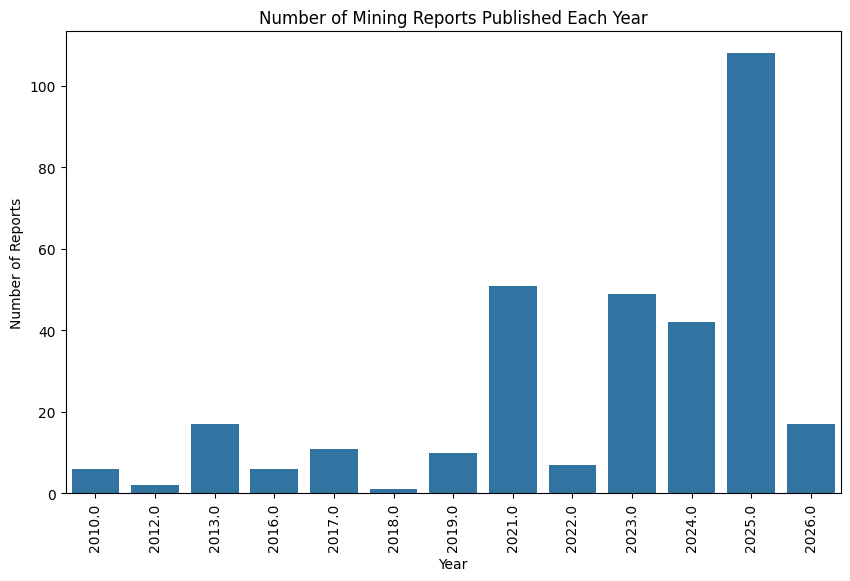

In [26]:
# what year are the reports in 
dates = pd.to_datetime(mining_data['Date of Observation']).dt.year.value_counts().sort_index()

# graph of dates 
plt.figure(figsize=(10,6))
sns.barplot(x=dates.index, y=dates.values)
plt.xticks(rotation=90)
plt.title("Number of Mining Reports Published Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Reports")
plt.show()

In [27]:
# get all links and download them from the Pictures column in mining_data 

In [28]:
import os
from urllib.parse import urlparse

import urllib.request

out_dir = "mining_pictures"
os.makedirs(out_dir, exist_ok=True)

picture_urls = mining_data["Pictures"].dropna().unique()

for idx, url in enumerate(picture_urls, start=1):
    try:
        parsed = urlparse(url)
        basename = os.path.basename(parsed.path) or f"picture_{idx}"
        name, ext = os.path.splitext(basename)
        if not ext:
            ext = ".jpg"
        filename = f"{idx:03d}_{name}{ext}"
        filepath = os.path.join(out_dir, filename)
        urllib.request.urlretrieve(url, filepath)
        print(f"downloaded {url} -> {filepath}")
    except Exception as e:
        print(f"failed to download {url}: {e}")

downloaded https://storage.googleapis.com/download/storage/v1/b/ved_prod__media/o/images%2Fimg_20160617_103012_56a865c7-7bdf-4f1c-9275-16b84ba22303.jpeg?generation=1687766819526489&alt=media -> mining_pictures/001_images%2Fimg_20160617_103012_56a865c7-7bdf-4f1c-9275-16b84ba22303.jpeg
downloaded https://storage.googleapis.com/download/storage/v1/b/ved_prod__media/o/images%2Fimg_20160616_142838_d50bdf50-cb68-4d49-a60b-2b0def846736.jpeg?generation=1688574852800728&alt=media -> mining_pictures/002_images%2Fimg_20160616_142838_d50bdf50-cb68-4d49-a60b-2b0def846736.jpeg
downloaded https://storage.googleapis.com/download/storage/v1/b/ved_prod__media/o/images%2Fscreenshot_2023_07_05_at_10_ebb1ea41-1f12-40f1-8fe7-04e6ea045ac2.jpeg?generation=1688575596417900&alt=media -> mining_pictures/003_images%2Fscreenshot_2023_07_05_at_10_ebb1ea41-1f12-40f1-8fe7-04e6ea045ac2.jpeg
downloaded https://storage.googleapis.com/download/storage/v1/b/ved_prod__media/o/images%2Fimg_20160803_181420145_hdr_d3eac81d-0d

what we have right now 
- mining dates of observations don't give us much 
- however, can compare mining data based on reports vs areas' formal reports and see correlation 

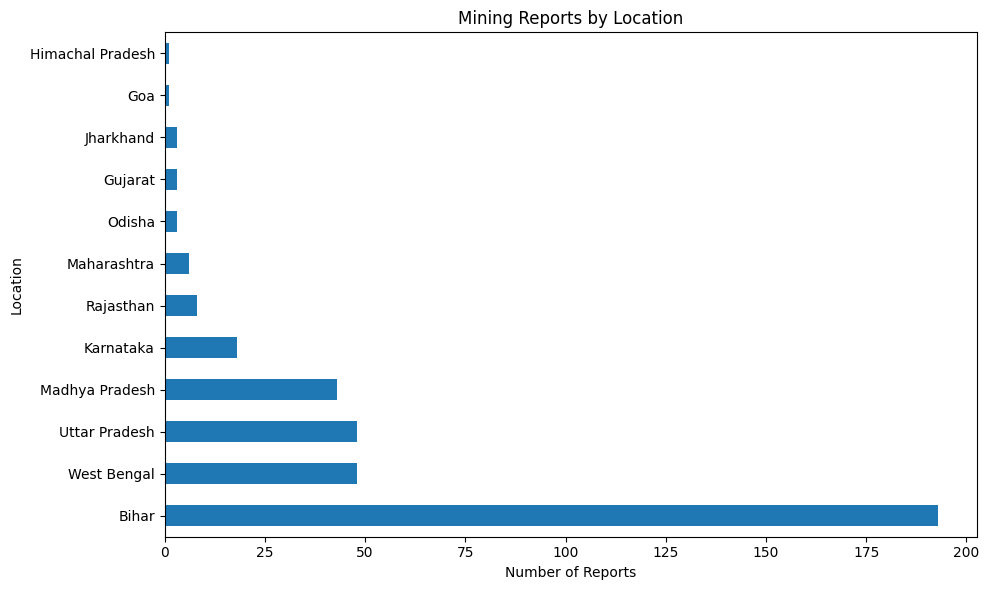

In [32]:
mining_data['State'].value_counts().plot(kind='barh', figsize=(10,6))
plt.xlabel("Number of Reports")
plt.ylabel("Location")
plt.title("Mining Reports by Location")
plt.tight_layout()
plt.show()

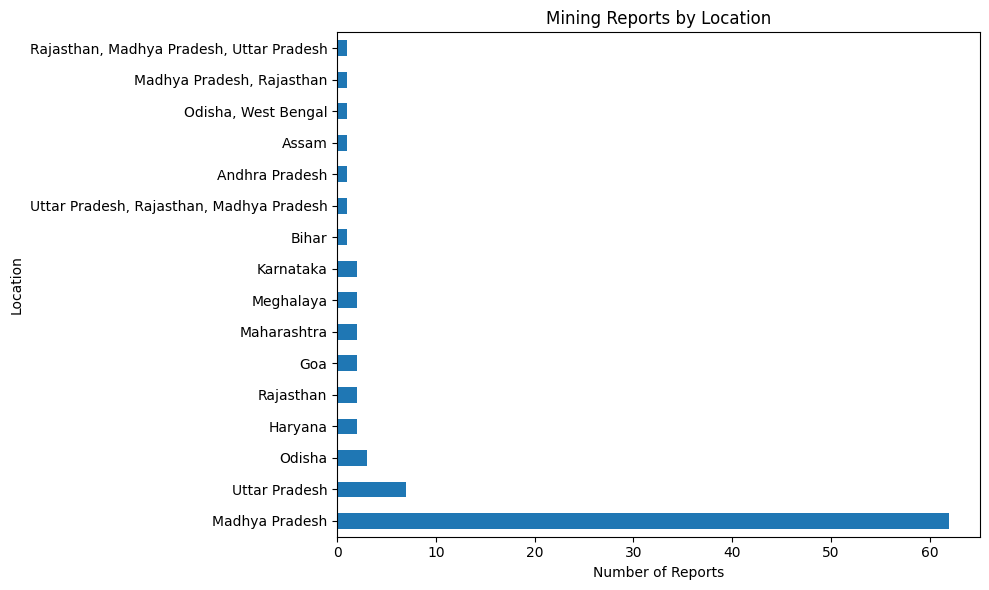

In [33]:
court_docs['State'].value_counts().plot(kind='barh', figsize=(10,6))
plt.xlabel("Number of Reports")
plt.ylabel("Location")
plt.title("Mining Reports by Location")
plt.tight_layout()
plt.show()

official reports for bihar are way lesser than unofficial 
official reports for MP are way more 

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

mp_docs = court_docs[court_docs['State'] == 'Madhya Pradesh']

summaries = mp_docs['Summary'].dropna()

vectorizer = TfidfVectorizer(max_features=50, stop_words='english', lowercase=True)
tfidf_matrix = vectorizer.fit_transform(summaries)

feature_names = vectorizer.get_feature_names_out()
top_terms = feature_names[tfidf_matrix.sum(axis=0).A1.argsort()[-20:]]

print("Top terms in Madhya Pradesh court documents:")
print(top_terms)

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(tfidf_matrix)

print("\nTop topics in MP court documents:")
for idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[-5:]]
    print(f"Topic {idx}: {', '.join(top_words)}")

Top terms in Madhya Pradesh court documents:
['application' 'section' '2020' 'act' 'report' 'guidelines' 'ngt'
 'committee' 'river' 'district' 'tribunal' 'ec' 'state' 'madhya' 'pradesh'
 'court' 'environmental' 'illegal' 'sand' 'mining']

Top topics in MP court documents:
Topic 0: minerals, rules, act, section, court
Topic 1: 2020, state, action, activities, 2023
Topic 2: ec, environmental, illegal, sand, mining
Topic 3: court, order, rule, dated, 2023
Topic 4: 2020, state, action, activities, 2023


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

mp_docs = court_docs[court_docs['State'] == 'Madhya Pradesh']

summaries = mp_docs['Summary'].dropna()

summaries = summaries.str.lower().str.replace(r'[^a-z\s]', '', regex=True).str.strip()

custom_stop_words = ['data', 'report', 'observation', 'based', 'generated', 'indian', 'india', 'watch', 'email', 'org', 'veditum', 'sandwatch', 'sightings', 'directly', 'field']
vectorizer = TfidfVectorizer(max_features=100, stop_words=custom_stop_words + list(TfidfVectorizer(stop_words='english').get_stop_words()), lowercase=True, ngram_range=(1,2))
tfidf_matrix = vectorizer.fit_transform(summaries)

feature_names = vectorizer.get_feature_names_out()
top_terms = feature_names[tfidf_matrix.sum(axis=0).A1.argsort()[-20:]]

print("Top terms in Madhya Pradesh court documents:")
print(top_terms)

lda = LatentDirichletAllocation(n_components=10, random_state=42, max_iter=10)
lda.fit(tfidf_matrix)

print("\nTop topics in MP court documents:")
for idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[-5:]]
    print(f"Topic {idx}: {', '.join(top_words)}")

Top terms in Madhya Pradesh court documents:
['section' 'act' 'ngt' 'committee' 'illegal mining' 'tribunal'
 'guidelines' 'ec' 'district' 'river' 'state' 'madhya' 'madhya pradesh'
 'pradesh' 'court' 'environmental' 'sand mining' 'illegal' 'sand' 'mining']

Top topics in MP court documents:
Topic 0: oa, minor, action, section, granted
Topic 1: environmental, sand mining, illegal, sand, mining
Topic 2: pradesh, madhya pradesh, madhya, dated, matter
Topic 3: minerals, rules, act, section, court
Topic 4: oa, minor, action, section, granted
Topic 5: proper, enforcement, violations, alleged, oa
Topic 6: oa, minor, action, section, granted
Topic 7: oa, minor, action, section, granted
Topic 8: minerals, minor, seiaa, granted, dsr
Topic 9: oa, minor, action, section, granted


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

mp_docs = mining_data[mining_data['State'] == 'Bihar']

summaries = mp_docs['Notes from the location'].dropna()

vectorizer = TfidfVectorizer(max_features=50, stop_words='english', lowercase=True)
tfidf_matrix = vectorizer.fit_transform(summaries)

feature_names = vectorizer.get_feature_names_out()
top_terms = feature_names[tfidf_matrix.sum(axis=0).A1.argsort()[-20:]]

print("Top terms in Madhya Pradesh court documents:")
print(top_terms)

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(tfidf_matrix)

print("\nTop topics in MP court documents:")
for idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[-5:]]
    print(f"Topic {idx}: {', '.join(top_words)}")

Top terms in Madhya Pradesh court documents:
['directly' 'field' 'india' 'watch' 'report' 'email' 'org' 'indian'
 'generated' 'sandwatch' 'rivers' 'sightings' 'veditum' 'observation'
 'based' 'data' 'wct' 'observations' 'mining' 'sand']

Top topics in MP court documents:
Topic 0: mining, sand, tractor, construction, bridge
Topic 1: observation, veditum, observations, sand, mining
Topic 2: raft, mining, sand, wct, data
Topic 3: skimming, data, wct, dredger, excavation
Topic 4: tractors, river, used, jcb, location


In [40]:
court_docs.head()

,Title,Link to the case on court sites / other sites,PDF,Type of Document,Summary,Start Date/ Registration date/ original application date of the case (as applicable),Application number / case number / diary number (as applicable),Type of Application,Case status,Date of case disposal,...,Additional notes,What is the focus area for this case?,State,District,Sub district / Tehsil,Rivers / Streams,Court,High Court,National Green Tribunal (NGT) zone/bench,Published Date
0,Deepak Kumar Etc vs State Of Haryana & Ors.Etc...,https://indiankanoon.org/doc/60071241/#:~:text...,https://storage.googleapis.com/download/storag...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Haryana,NaN,NaN,"yamuna, Ghaggar, Tangri, Markanda, Krishnavati...",Supreme Court,NaN,NaN,06-01-2023
1,"Court Order, 21/07/2023 - Munish vs Haryana St...",https://greentribunal.gov.in/gen_pdf_test.php?...,https://storage.googleapis.com/download/storag...,Orders,Major comment (1) + instructions (2)\n\n1. The...,17-04-2023 18:30:00,OA 269 / 2023,Original Application,Pending,NaN,...,-,Regional,Haryana,Sonipat,NaN,yamuna,National Green Tribunal (NGT),NaN,North zone - Delhi (Principal bench),08-08-2023
2,"Court Order, 05/08/2022 - Akshay Kumar Tripath...",https://greentribunal.gov.in/caseDetails/KOLKA...,https://storage.googleapis.com/download/storag...,Orders,The matter related to illegal mining of sand i...,22-09-2021 18:30:00,OA 84 / 2021,Original Application,Disposed,05-08-2022 18:30:00,...,-,Regional,Odisha,Bhadrak,Bhandari Pokhari,Baitrani,National Green Tribunal (NGT),NaN,East zone - Kolkata,11-08-2023
3,"Court Order, 06/02/2023 - News item published ...",https://greentribunal.gov.in/caseDetails/DELHI...,NaN,Orders,The matter was taken up on the basis of a medi...,30-03-2022 18:30:00,OA 248 / 2022,Original Application,Pending,NaN,...,https://www.thehindu.com/society/an-ecocide-is...,Regional,Rajasthan,Dhaulpur,NaN,Chambal,National Green Tribunal (NGT),NaN,North zone - Delhi (Principal bench),17-08-2023
4,"Court Order, 29/09/2022 - Ajit Kumar vs State ...",https://greentribunal.gov.in/caseDetails/BHOPA...,NaN,Orders,The issue of non-compliance of sustainable San...,07-05-2022 18:30:00,OA 38 / 2022,Original Application,Disposed,29-09-2022 18:30:00,...,-,Regional,Madhya Pradesh,Dewas,NaN,"Narmada, Kali Sindh, Shipra",National Green Tribunal (NGT),NaN,Central zone - Bhopal,21-08-2023
